In [1]:
from ipyopenlayers import (
    Map, DrawAndExport, ScaleLine, GeoTIFFTileLayer,ZoomSlider, RasterTileLayer
)

In [3]:
m=Map(center=[-122.2264,37.0642],zoom=15)
m.add_control(ZoomSlider())
m.add_control(DrawAndExport())
m

Map(center=[-122.2264, 37.0642], zoom=15.0)

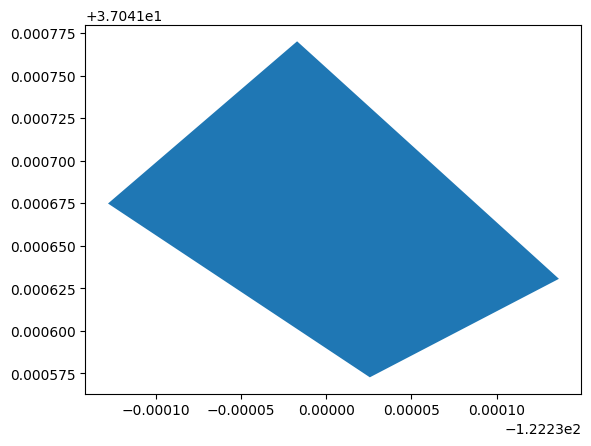

generated on 2026-04-27T21:20:14.764Z


In [9]:

import shapely
import matplotlib.pyplot as plt

export = """{"type":"FeatureCollection","features":[{"type":"Feature","geometry":{"type":"Polygon","coordinates":[[[-122.22986339123666,37.04163061698293],[-122.22997433107012,37.04157274255442],[-122.23012793931908,37.04167487370867],[-122.23001699997391,37.04177019609922],[-122.22986339123666,37.04163061698293]]]},"properties":null}]}"""
plt.fill(
    shapely.get_coordinates(exported_shapely)[:, 0],
    shapely.get_coordinates(exported_shapely)[:, 1],
)
plt.show()
print("generated on 2026-04-27T21:20:14.764Z")
      

In [ ]:

import shapely
import matplotlib.pyplot as plt

export= """{"type":"FeatureCollection","features":[{"type":"Feature","geometry":{"type":"Polygon","coordinates":[[[-122.23006210185105,37.041742850093456],[-122.23012557854356,37.04168541344336],[-122.22995207532577,37.04154351053572],[-122.2298801352034,37.041638112503634],[-122.23006210185105,37.041742850093456]]]},"properties":null}]}"""
plt.fill(
    shapely.get_coordinates(exported_shapely)[:, 0],
    shapely.get_coordinates(exported_shapely)[:, 1],
)
plt.show()
print("generated on 2026-04-27T20:51:46.874Z")
      

In [10]:
zonal_stats(export, "ndvi.tif", stats=['mean'])

[{'mean': 0.5110412773429389}]

In [4]:
from jupyter_xarray_tiler import titiler as tiler
import rioxarray
from rasterstats import zonal_stats
import numpy as np
import rasterio

In [5]:
da = rioxarray.open_rasterio("ortho-small.tif")

da

<xarray.DataArray (band: 8, y: 1843, x: 1638)> Size: 48MB
[24150672 values with dtype=uint16]
Coordinates:
  * band         (band) int64 64B 1 2 3 4 5 6 7 8
  * y            (y) float64 15kB 37.04 37.04 37.04 37.04 ... 37.04 37.04 37.04
  * x            (x) float64 13kB -122.2 -122.2 -122.2 ... -122.2 -122.2 -122.2
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Red', 'Green', 'Blue', 'Green', 'Red', 'RedEdge', 'NIR'...

In [6]:
tile_url = await tiler.add_data_array(da.sel(band=[1, 2, 3]))
tile_url

[2026-04-27 14:18:48 -0700] [73925] [INFO] Running on http://127.0.0.1:40741 (CTRL + C to quit)


'/proxy/40741/41acd04b-f1f8-4556-9513-89f4f74e97d0/tiles/WebMercatorQuad/{z}/{x}/{y}.png?scale=1&colormap_name=viridis&reproject=max'

In [ ]:
layer = RasterTileLayer(url=tile_url)
m.add_layer(layer)

In [7]:
layer = GeoTIFFTileLayer(url="https://mfisher87.github.io/orthomosaic-for-benny/ortho-small.tif")
m.add_layer(layer)

In [ ]:
with rasterio.open("ortho.tif") as src:
    r, nir = src.read(1).astype(float), src.read(7).astype(float)
    p = src.profile

ndvi = (nir - r) / (nir + r)
p.update(count=1, dtype="float32")

with rasterio.open("ndvi.tif", "w", **p) as dst:
    dst.write(ndvi.astype("float32"), 1)

In [ ]:
ndvi = (
    (da.NIR - data.Red) / (data.NIR + data.RED)
).where(
    lambda ndvi: ndvi < 1
).compute()

ndvi.plot.imshow();